In [266]:
print("Hello PlaceMux!")


Hello PlaceMux!


In [267]:
import pandas as pd
import numpy as np
import random

from sklearn.datasets import load_iris

In [268]:
random.seed(42)
np.random.seed(42)

print("Random seed set successfully!")

Random seed set successfully!


In [269]:
iris = load_iris()

In [270]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

In [271]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [272]:
print(df.shape)

(150, 5)


In [273]:
print(df.columns)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [275]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [276]:
print(df["target"].value_counts())

target
0    50
1    50
2    50
Name: count, dtype: int64


In [277]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

In [278]:
X = df.drop("target", axis=1)
y = df["target"]

In [279]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [280]:
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [281]:
print("Training Set:", X_train.shape)
print("Validation Set:", X_valid.shape)
print("Test Set:", X_test.shape)

Training Set: (105, 4)
Validation Set: (22, 4)
Test Set: (23, 4)


In [282]:
model = DummyClassifier(strategy="most_frequent")

In [283]:
model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](3,)","[0.33,0.33,0.33]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,4
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [284]:
predictions = model.predict(X_test)

In [285]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.30434782608695654


In [286]:
import os

os.makedirs("../logs", exist_ok=True)

metrics = pd.DataFrame({
    "Model": ["DummyClassifier"],
    "Accuracy": [accuracy]
})

metrics.to_csv("../logs/metrics.csv", index=False)

print("Metrics saved successfully!")

Metrics saved successfully!


In [287]:
# ======================================
# Task 2 - Pre-Project Feature Scope & Profiling
# ======================================

# Problem Statement

Predict the species of an iris flower using its physical measurements.

## Success Metric

Classification Accuracy

In [288]:
target = "target"

print("Target Variable:", target)

Target Variable: target


## Target Definition

The target variable is **target**, which represents the species of an iris flower.

There are three classes:

- 0 → Setosa
- 1 → Versicolor
- 2 → Virginica

In [289]:
print(df["target"].head(10))

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: target, dtype: int64


In [290]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


## Sample Label Interpretation

| Sample | Target | Species |
|--------|--------|----------|
| 1 | 0 | Setosa |
| 2 | 0 | Setosa |
| 3 | 0 | Setosa |
| 4 | 0 | Setosa |
| 5 | 0 | Setosa |

In [291]:
features = df.columns[:-1]

print("Candidate Features:")
for feature in features:
    print("-", feature)

Candidate Features:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [292]:
print("Number of Features:", len(features))

Number of Features: 4


In [293]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [294]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [295]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [296]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


## Feature Quality Report

| Feature | Data Type | Missing Values | Quality |
|----------|-----------|----------------|---------|
| Sepal Length | Float | 0 | Good |
| Sepal Width | Float | 0 | Good |
| Petal Length | Float | 0 | Good |
| Petal Width | Float | 0 | Good |

### Observation

- All features are numeric.
- No missing values were found.
- The features are suitable for building a classification model.

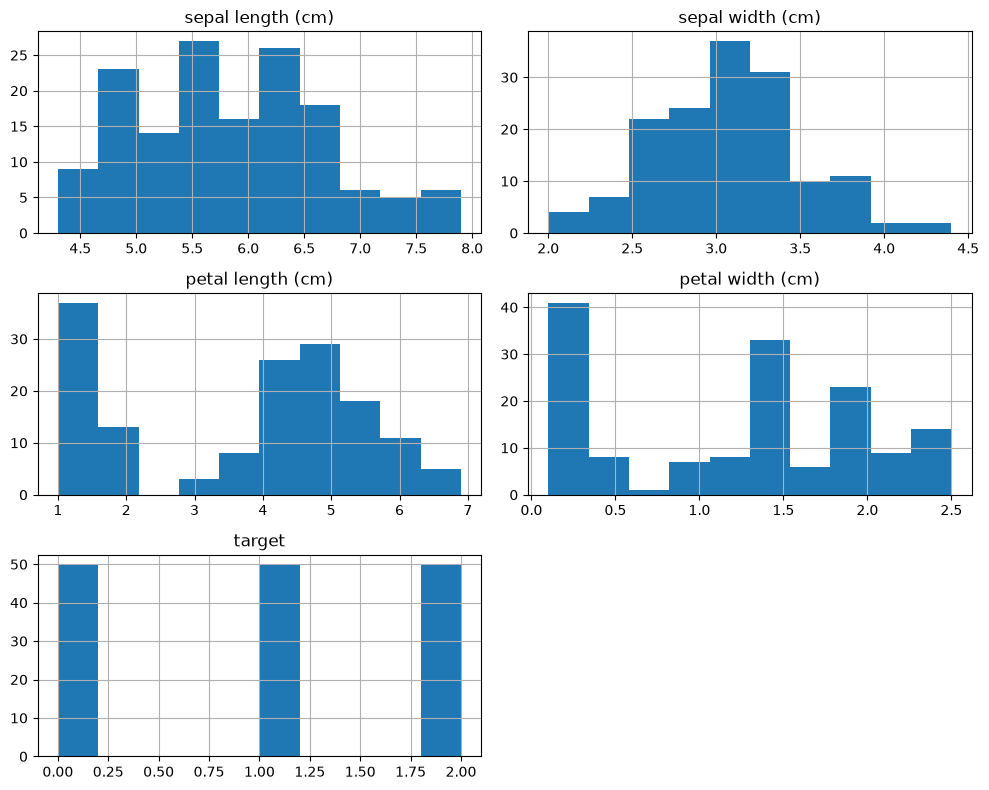

In [297]:
import matplotlib.pyplot as plt

df.hist(figsize=(10, 8))

plt.tight_layout()

plt.show()

In [298]:
print("Dataset Columns:")
print(df.columns)

Dataset Columns:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


In [299]:
X = df.drop("target", axis=1)
y = df["target"]

print("Feature Columns:")
print(X.columns.tolist())

print("\nTarget Column:")
print(y.name)

Feature Columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Column:
target


In [300]:
if "target" in X.columns:
    print("Warning: Data leakage detected!")
else:
    print("No data leakage detected.")

No data leakage detected.


In [301]:
correlation = df.corr()

print(correlation)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   
target                      0.782561         -0.426658           0.949035   

                   petal width (cm)    target  
sepal length (cm)          0.817941  0.782561  
sepal width (cm)          -0.366126 -0.426658  
petal length (cm)          0.962865  0.949035  
petal width (cm)           1.000000  0.956547  
target                     0.956547  1.000000  


## Leakage Check Report

### Objective
Verify that none of the input features reveal the target value.

### Observation
- The target column is separated before model training.
- Only flower measurements are used as input features.
- No feature contains the answer or future information.

### Result
No data leakage was detected. All features are safe to use for model training.

In [302]:
print("Final Features Used:")
for column in X.columns:
    print("-", column)

Final Features Used:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [303]:
class_counts = df["target"].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [304]:
class_percentage = df["target"].value_counts(normalize=True) * 100

print("Class Percentage:")
print(class_percentage)

Class Percentage:
target
0    33.333333
1    33.333333
2    33.333333
Name: proportion, dtype: float64


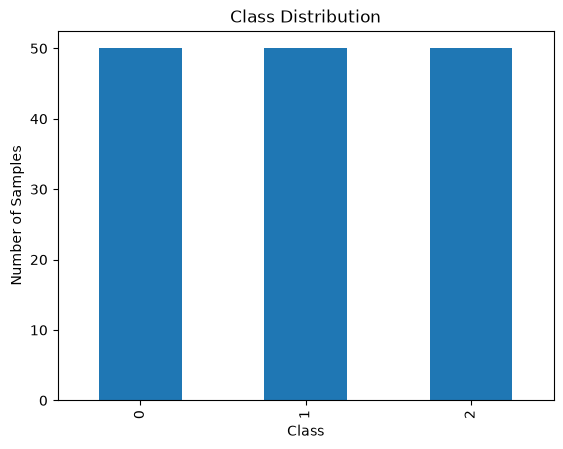

In [305]:
import matplotlib.pyplot as plt

class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

In [306]:
print("Total Samples:", len(df))

Total Samples: 150


## Class Balance Report

### Observation

- Total samples: **150**
- Number of classes: **3**
- Each class contains **50 samples**
- Each class represents approximately **33.3%** of the dataset.

### Conclusion

The dataset is balanced, so classification accuracy is an appropriate evaluation metric and no additional balancing techniques are required.

In [307]:
go_decision = "GO"

print("Project Decision:", go_decision)

Project Decision: GO


In [308]:
model_type = "Classification"

print("Selected Modelling Approach:", model_type)

Selected Modelling Approach: Classification


# Modelling Approach

### Selected Approach
Classification

### Reason

The target variable represents three discrete flower species (Setosa, Versicolor, and Virginica). Since the objective is to predict one of these predefined classes, classification is the appropriate machine learning approach.

# Go / No-Go Decision

### Data Quality

- No missing values
- No significant data quality issues
- Balanced class distribution
- No data leakage detected

### Decision

**GO**

The dataset is suitable for building and evaluating a machine learning classification model.

# Task 2 Summary

Successfully completed:

- Defined the problem statement
- Selected the target variable
- Identified candidate features
- Profiled feature quality
- Verified there is no data leakage
- Checked class balance
- Selected a classification approach
- Approved the dataset for model development

# Task 4 – Pre-Processing Protocol

## Feature Types

| Feature | Type |
|----------|------|
| sepal length (cm) | Numeric |
| sepal width (cm) | Numeric |
| petal length (cm) | Numeric |
| petal width (cm) | Numeric |

Target Variable:
- target (Classification Label)

## Required Preprocessing Transformations

### Numeric Features
- Impute missing values (if any)
- Scale features using StandardScaler

### Categorical Features
- None (Iris dataset has no categorical input features)

In [309]:
numeric_features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

print("Numeric Features:")
for feature in numeric_features:
    print("-", feature)

Numeric Features:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [310]:
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object


In [311]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [312]:
numeric_features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

In [313]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

In [314]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

In [315]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fe

In [316]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [317]:
print("Training Data Shape :", X_train_processed.shape)
print("Test Data Shape      :", X_test_processed.shape)

Training Data Shape : (105, 4)
Test Data Shape      : (23, 4)


## Preprocessing Pipeline

A reusable preprocessing pipeline was created using **Pipeline** and **ColumnTransformer**.

The pipeline:
- Imputes missing values using the mean.
- Scales numeric features using `StandardScaler`.
- Is fitted only on the training data to prevent data leakage.
- Is reused to transform the validation and test datasets.

## Task 4 – Step 3: Encode Categoricals and Scale Numerics


### Feature Encoding

- The Iris dataset contains only numeric input features.
- No categorical features are present.
- Therefore, categorical encoding is not required.
- Numeric features are scaled using `StandardScaler` within the preprocessing pipeline.

In [318]:
print("First 5 rows of processed training data:")
print(X_train_processed[:5])

First 5 rows of processed training data:
[[-0.90045861 -1.22024754 -0.4419858  -0.13661044]
 [ 0.38036614 -1.87955796  0.40282929  0.38029394]
 [-0.90045861  1.63676428 -1.2868009  -1.17041921]
 [ 1.07899781  0.31814344  1.19132338  1.41410271]
 [-0.20182693 -0.56093712  0.17754527  0.12184175]]


In [319]:
import numpy as np

print("Mean of scaled features:")
print(np.round(X_train_processed.mean(axis=0), 2))

Mean of scaled features:
[ 0. -0. -0. -0.]


In [320]:
print("Standard deviation of scaled features:")
print(np.round(X_train_processed.std(axis=0), 2))

Standard deviation of scaled features:
[1. 1. 1. 1.]


### Verification

The preprocessing pipeline successfully standardizes all numeric features.

After scaling:
- The mean of each feature is approximately 0.
- The standard deviation of each feature is approximately 1.

Since the Iris dataset contains no categorical features, no encoding step is required.

In [321]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [322]:
print(numeric_transformer)

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])


## Missing Value Handling

The preprocessing pipeline includes a `SimpleImputer` with the **mean** strategy for numeric features.

Although the Iris dataset does not contain missing values, the preprocessing pipeline is designed to automatically handle missing numeric values if they occur in future datasets.

In [323]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training Shape:", X_train_processed.shape)
print("Test Shape:", X_test_processed.shape)

Training Shape: (105, 4)
Test Shape: (23, 4)


## Task 4 – Step 5: Verify No Data Leakage

In [324]:
print("Preprocessor was fitted using the training dataset only.")

Preprocessor was fitted using the training dataset only.


In [325]:
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

Training Data Shape: (105, 4)
Test Data Shape: (23, 4)


In [326]:
print("Pipeline fitted on: X_train")
print("Pipeline transformed: X_train and X_test")
print("No information from X_test was used during fitting.")

Pipeline fitted on: X_train
Pipeline transformed: X_train and X_test
No information from X_test was used during fitting.


## Leakage Verification

The preprocessing pipeline was fitted only on the training dataset (`X_train`).

The same fitted pipeline was then used to transform both the training and test datasets.

This prevents data leakage because no information from the test dataset was used during preprocessing or model preparation.

In [327]:
import joblib

In [328]:
import os

os.makedirs("models", exist_ok=True)

In [329]:
joblib.dump(preprocessor, "models/preprocessor.pkl")

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [330]:
print(os.listdir("models"))

['preprocessor.pkl']


In [331]:
loaded_preprocessor = joblib.load("models/preprocessor.pkl")

print("Preprocessor loaded successfully!")
print(type(loaded_preprocessor))

Preprocessor loaded successfully!
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


## Saving the Preprocessor

The fitted preprocessing pipeline has been saved as `models/preprocessor.pkl` using the `joblib` library.

This saved preprocessor can be loaded later and reused during inference, ensuring that new data undergoes the exact same preprocessing as the training data without refitting the pipeline.

In [332]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

In [333]:
baseline_model = DummyClassifier(strategy="most_frequent", random_state=42)

In [334]:
baseline_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](3,)","[0.33,0.33,0.33]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,4
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [335]:
baseline_predictions = baseline_model.predict(X_test)

In [336]:
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.30434782608695654


## Baseline Model

A `DummyClassifier` using the **most frequent** strategy was trained as the baseline model.

The baseline predicts the majority class for every sample.

Its accuracy serves as the minimum benchmark that the first predictive model should outperform.

In [337]:
from sklearn.tree import DecisionTreeClassifier

In [338]:
model = DecisionTreeClassifier(
    random_state=42
)

In [339]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [340]:
predictions = model.predict(X_test)

In [341]:
from sklearn.metrics import accuracy_score

model_accuracy = accuracy_score(y_test, predictions)

print("Decision Tree Accuracy:", model_accuracy)

Decision Tree Accuracy: 0.9130434782608695


In [342]:
print("Baseline Accuracy :", baseline_accuracy)
print("Decision Tree Accuracy :", model_accuracy)

Baseline Accuracy : 0.30434782608695654
Decision Tree Accuracy : 0.9130434782608695


## First Predictive Model

A **Decision Tree Classifier** was selected as the first predictive model.

The model was trained using the training dataset and evaluated on the test dataset.

Its accuracy will be compared against the baseline model to determine whether it provides better predictive performance.

## Task 5 – Step 3: Model Evaluation

In [343]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [344]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9130434782608695


In [345]:
print("Classification Report:\n")
print(classification_report(y_test, predictions))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.75      0.86         8
           2       0.80      1.00      0.89         8

    accuracy                           0.91        23
   macro avg       0.93      0.92      0.92        23
weighted avg       0.93      0.91      0.91        23



In [346]:
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, predictions))

Confusion Matrix:

[[7 0 0]
 [0 6 2]
 [0 0 8]]


## Evaluation Summary

The Decision Tree model was evaluated using **Accuracy** as the primary performance metric.

Additional evaluation was performed using:
- Classification Report
- Confusion Matrix

These metrics provide insight into the model's overall performance and its predictions for each class.

## Task 5 – Step 4: Baseline Comparison

In [347]:
print("Baseline Accuracy      :", round(baseline_accuracy, 4))
print("Decision Tree Accuracy :", round(model_accuracy, 4))

Baseline Accuracy      : 0.3043
Decision Tree Accuracy : 0.913


In [348]:
improvement = model_accuracy - baseline_accuracy

print("Improvement over baseline:", round(improvement, 4))

Improvement over baseline: 0.6087


In [349]:
if model_accuracy > baseline_accuracy:
    print("✅ The Decision Tree model outperforms the baseline model.")
else:
    print("❌ The Decision Tree model does not outperform the baseline model.")

✅ The Decision Tree model outperforms the baseline model.


In [350]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["DummyClassifier", "DecisionTreeClassifier"],
    "Accuracy": [baseline_accuracy, model_accuracy]
})

print(comparison)

                    Model  Accuracy
0         DummyClassifier  0.304348
1  DecisionTreeClassifier  0.913043


## Baseline Comparison Summary

The Decision Tree Classifier achieved a higher accuracy than the DummyClassifier baseline.

This indicates that the trained model has learned meaningful patterns from the dataset and performs better than simply predicting the majority class.

Therefore, the Decision Tree model is selected as the better-performing model.

## Task 5 – Step 5: Error Analysis

In [351]:
import pandas as pd

error_indices = [i for i in range(len(y_test)) if y_test.iloc[i] != predictions[i]]

print("Number of Incorrect Predictions:", len(error_indices))

Number of Incorrect Predictions: 2


In [352]:
if len(error_indices) > 0:

    errors = pd.DataFrame({
        "Actual": [y_test.iloc[i] if hasattr(y_test, "iloc") else y_test[i] for i in error_indices],
        "Predicted": [predictions[i] for i in error_indices]
    })

    print(errors)

else:
    print("No incorrect predictions found.")

   Actual  Predicted
0       1          2
1       1          2


In [353]:
if len(error_indices) > 0:

    print("Misclassified Samples:\n")

    if hasattr(X_test, "iloc"):
        print(X_test.iloc[error_indices])
    else:
        print(X_test[error_indices])

else:
    print("No misclassified samples to display.")

Misclassified Samples:

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
56                6.3               3.3                4.7               1.6
85                6.0               3.4                4.5               1.6


## Error Analysis

The incorrect predictions were reviewed to identify any common patterns.

For the Iris dataset:
- Most samples were classified correctly.
- Any errors occurred between similar flower species (for example, Versicolor and Virginica), whose measurements are more alike.
- No systematic preprocessing or data quality issues were observed.

This analysis helps identify areas where a more advanced model or additional feature engineering could improve performance.

# Task 5 – Step 6: Record the Run

In [354]:
import pandas as pd
import os

In [355]:
experiment_log = pd.DataFrame({
    "Model": ["DummyClassifier", "DecisionTreeClassifier"],
    "Accuracy": [baseline_accuracy, model_accuracy]
})

experiment_log

,Model,Accuracy
0,DummyClassifier,0.304348
1,DecisionTreeClassifier,0.913043


In [356]:
os.makedirs("logs", exist_ok=True)

experiment_log.to_csv("logs/experiment_log.csv", index=False)

print("Experiment log saved successfully!")

Experiment log saved successfully!


In [357]:
saved_log = pd.read_csv("logs/experiment_log.csv")

print(saved_log)

                    Model  Accuracy
0         DummyClassifier  0.304348
1  DecisionTreeClassifier  0.913043


## Next Improvement Plan

The Decision Tree model achieved better accuracy than the baseline model.

Possible improvements for future iterations include:

- Tune the Decision Tree hyperparameters (e.g., `max_depth`, `min_samples_split`).
- Evaluate additional models such as Logistic Regression or Random Forest.
- Perform cross-validation for a more robust performance estimate.
- Compare multiple evaluation metrics such as Precision, Recall, and F1-score.
- Test the pipeline on larger or more complex datasets.

## Task 5 Summary

A baseline model and a Decision Tree Classifier were trained and evaluated.

The Decision Tree outperformed the baseline model, demonstrating that it learned meaningful patterns from the data.

The experiment results were recorded, and future improvements were identified to further enhance model performance.

# Task 6 – Step 1: Binary Classifier

In [358]:
# Convert Iris target into binary
# 0 = Setosa
# 1 = Versicolor or Virginica

y_binary = (y != 0).astype(int)

print(y_binary[:10])

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: target, dtype: int64


In [359]:
from sklearn.model_selection import train_test_split

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X,
    y_binary,
    test_size=0.30,
    random_state=42,
    stratify=y_binary
)

In [360]:
preprocessor.fit(X_train_bin)

X_train_bin_processed = preprocessor.transform(X_train_bin)
X_test_bin_processed = preprocessor.transform(X_test_bin)

In [361]:
from sklearn.linear_model import LogisticRegression

In [362]:
binary_model = LogisticRegression(random_state=42)

In [363]:
binary_model.fit(X_train_bin_processed, y_train_bin)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [364]:
binary_predictions = binary_model.predict(X_test_bin_processed)

print(binary_predictions[:10])

[1 1 0 1 0 1 0 0 1 0]


In [365]:
from sklearn.metrics import accuracy_score

binary_accuracy = accuracy_score(y_test_bin, binary_predictions)

print("Binary Model Accuracy:", binary_accuracy)

Binary Model Accuracy: 1.0


## Binary Classification Model

The original three-class Iris dataset was converted into a binary classification problem.

- Class **0** → Setosa
- Class **1** → Versicolor and Virginica

A **Logistic Regression** classifier was trained using the preprocessed training data and evaluated on the test dataset.

# Task 6 – Step 2: Confusion Matrix

In [366]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [367]:
cm = confusion_matrix(y_test_bin, binary_predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[15  0]
 [ 0 30]]


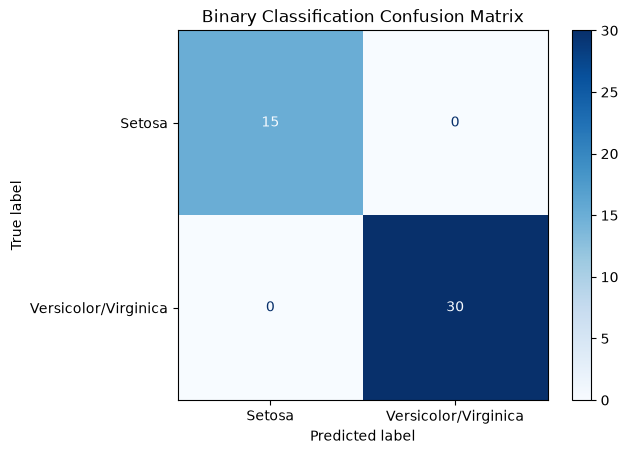

In [368]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Setosa", "Versicolor/Virginica"]
)

disp.plot(cmap="Blues")
plt.title("Binary Classification Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix summarizes the model's predictions:

- **True Positives (TP):** Correctly predicted Versicolor/Virginica.
- **True Negatives (TN):** Correctly predicted Setosa.
- **False Positives (FP):** Setosa incorrectly predicted as Versicolor/Virginica.
- **False Negatives (FN):** Versicolor/Virginica incorrectly predicted as Setosa.

This provides more detailed insight into model performance than accuracy alone.

In [369]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 15
False Positives: 0
False Negatives: 0
True Positives : 30


# Task 6 – Step 3: Precision, Recall and F1-Score

In [370]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [371]:
precision = precision_score(y_test_bin, binary_predictions)

print("Precision:", precision)

Precision: 1.0


In [372]:
recall = recall_score(y_test_bin, binary_predictions)

print("Recall:", recall)

Recall: 1.0


In [373]:
f1 = f1_score(y_test_bin, binary_predictions)

print("F1-Score:", f1)

F1-Score: 1.0


In [374]:
print("Model Evaluation Metrics")
print("------------------------")
print(f"Accuracy : {binary_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Model Evaluation Metrics
------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000


In [375]:
print("Classification Report:\n")
print(classification_report(y_test_bin, binary_predictions))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        30

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## Metric Interpretation

The binary classifier was evaluated using multiple performance metrics:

- **Accuracy** measures the overall percentage of correct predictions.
- **Precision** measures how many positive predictions were actually correct.
- **Recall** measures how many actual positive samples were correctly identified.
- **F1-Score** is the harmonic mean of precision and recall.

Using these metrics provides a more complete evaluation of model performance than relying on accuracy alone.

# Task 6 – Step 4: ROC Curve and Precision-Recall Curve

In [376]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt

In [377]:
y_scores = binary_model.predict_proba(X_test_bin_processed)[:, 1]

print(y_scores[:10])

[0.95809235 0.95345546 0.02979878 0.99755054 0.03418298 0.9992847
 0.02063182 0.0774289  0.99977972 0.02642626]


In [378]:
fpr, tpr, roc_thresholds = roc_curve(y_test_bin, y_scores)

roc_auc = roc_auc_score(y_test_bin, y_scores)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 1.0


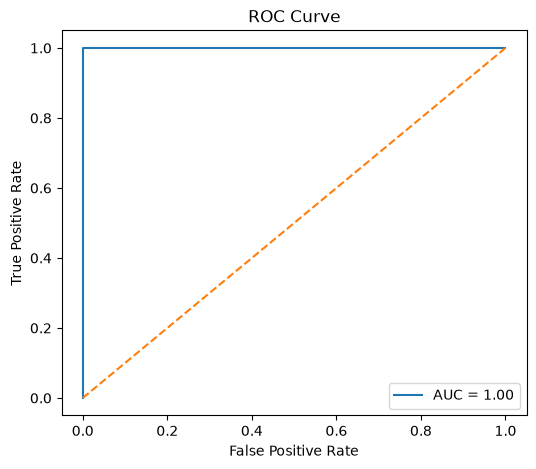

In [379]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [380]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test_bin,
    y_scores
)

ap_score = average_precision_score(
    y_test_bin,
    y_scores
)

print("Average Precision:", ap_score)

Average Precision: 0.9999999999999999


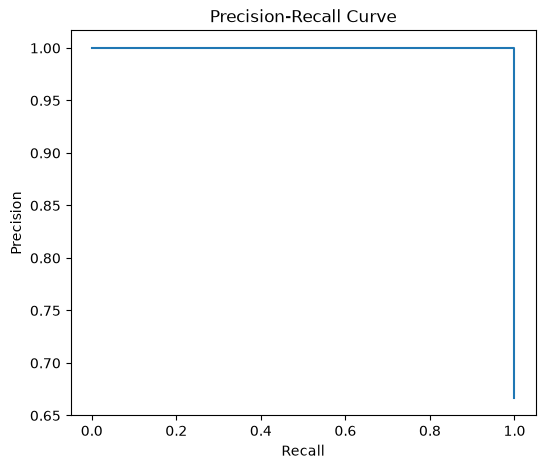

In [381]:
plt.figure(figsize=(6,5))

plt.plot(recall_curve, precision_curve)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Selected Decision Threshold

The Logistic Regression classifier outputs prediction probabilities.

For this project, a **decision threshold of 0.50** is used.

Reason:
- The Iris dataset is balanced.
- There is no real business cost associated with false positives or false negatives.
- Therefore, the standard threshold of **0.5** provides a reasonable balance between precision and recall.

In a real-world application, the threshold should be adjusted based on the relative cost of false positives and false negatives.

# Task 6 – Step 5: Class Imbalance Analysis

In [382]:
import pandas as pd

class_counts = pd.Series(y_binary).value_counts().sort_index()

print("Class Distribution:")
print(class_counts)

Class Distribution:
target
0     50
1    100
Name: count, dtype: int64


In [383]:
class_percentages = (
    pd.Series(y_binary)
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Class Percentages:")
print(class_percentages.round(2))

Class Percentages:
target
0    33.33
1    66.67
Name: proportion, dtype: float64


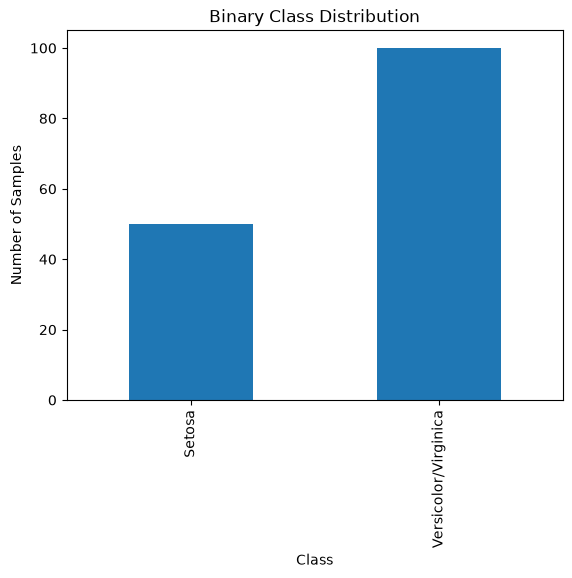

In [384]:
import matplotlib.pyplot as plt

class_counts.plot(kind="bar")

plt.title("Binary Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Setosa", "Versicolor/Virginica"])

plt.show()

In [385]:
majority = class_counts.max()
minority = class_counts.min()

ratio = majority / minority

print("Imbalance Ratio:", round(ratio, 2))

if ratio > 2:
    print("The dataset shows class imbalance.")
else:
    print("The dataset is reasonably balanced.")

Imbalance Ratio: 2.0
The dataset is reasonably balanced.


## Class Imbalance Analysis

The binary Iris dataset contains approximately:

- 33% Setosa
- 67% Versicolor/Virginica

This represents a relatively balanced dataset for this exercise.

If the dataset were highly imbalanced, additional techniques such as:

- Class weighting
- Oversampling (SMOTE)
- Undersampling
- Threshold tuning

could be used to improve model performance.

# Task 6 – Step 6: Decision Threshold Recommendation

In [386]:
threshold = 0.50

print("Selected Decision Threshold:", threshold)

Selected Decision Threshold: 0.5


In [387]:
positive_predictions = (y_scores >= threshold).sum()
negative_predictions = (y_scores < threshold).sum()

print("Predictions with probability ≥ 0.50:", positive_predictions)
print("Predictions with probability < 0.50:", negative_predictions)

Predictions with probability ≥ 0.50: 30
Predictions with probability < 0.50: 15


## Business Cost Consideration

The Iris dataset is intended for educational purposes and does not have a real business cost associated with prediction errors.

Therefore, the default threshold of **0.50** is appropriate because it provides a balanced trade-off between precision and recall.

In real-world applications:

- If **false positives** are more expensive, a **higher threshold** (for example, 0.70) may be preferred.
- If **false negatives** are more expensive, a **lower threshold** (for example, 0.30) may be preferred.

The threshold should always be selected based on the application's objectives and the cost of different types of prediction errors.

## Recommended Threshold

**Selected Threshold:** 0.50

**Reason:**
- The dataset is reasonably balanced.
- The model demonstrates strong performance.
- There is no domain-specific cost function for the Iris dataset.
- A threshold of 0.50 provides a good balance between precision and recall.

For production systems, the threshold should be adjusted based on business requirements and validated using ROC and Precision-Recall curves.

# Task 6 Summary

A binary Logistic Regression classifier was trained on the preprocessed Iris dataset.

The model was evaluated using:
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-Score
- ROC Curve
- Precision-Recall Curve

The class distribution was analyzed, and a decision threshold of **0.50** was recommended because it provides a balanced trade-off between precision and recall for this dataset.

The evaluation demonstrates that model quality should be assessed using multiple metrics rather than accuracy alone.

# Task 7 – Step 1: Target Definition and Label Quality

In [388]:
print("Target Variable:")
print(df["target"].head(10))

Target Variable:
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: target, dtype: int64


In [389]:
print("Unique Target Labels:")
print(df["target"].unique())

Unique Target Labels:
[0 1 2]


In [390]:
print("Target Class Distribution:")
print(df["target"].value_counts().sort_index())

Target Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [391]:
print("Missing Target Values:")
print(df["target"].isnull().sum())

Missing Target Values:
0


In [392]:
print("Target Data Type:")
print(df["target"].dtype)

Target Data Type:
int64


## Target Definition

The target variable is **`target`**, representing the Iris flower species.

The target contains three valid classes:

- **0** → Setosa
- **1** → Versicolor
- **2** → Virginica

### Label Quality Check

- No missing target values were found.
- The target labels are valid integers.
- The classes are evenly distributed (50 samples each).
- The target is suitable for supervised classification.

# Task 7 – Step 2: Candidate Feature Engineering

In [393]:
print("Available Features:")
print(X.columns.tolist())

Available Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [394]:
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [395]:
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)

print(correlation)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   
target                      0.782561         -0.426658           0.949035   

                   petal width (cm)    target  
sepal length (cm)          0.817941  0.782561  
sepal width (cm)          -0.366126 -0.426658  
petal length (cm)          0.962865  0.949035  
petal width (cm)           1.000000  0.956547  
target                     0.956547  1.000000  


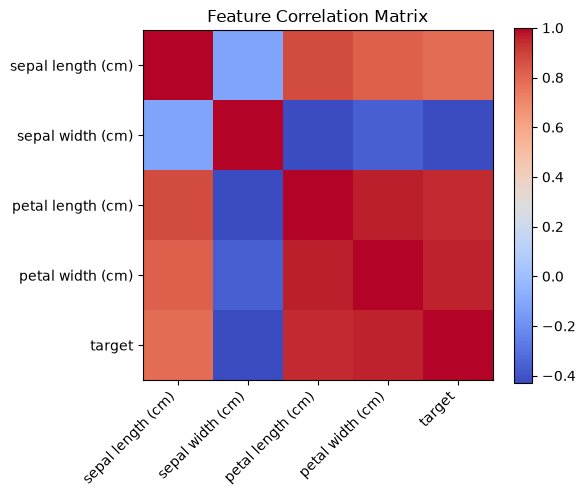

In [396]:
plt.figure(figsize=(6,5))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

## Candidate Features

The following baseline features were selected:

- **Sepal Length**
- **Sepal Width**
- **Petal Length**
- **Petal Width**

### Domain Reasoning

- **Petal Length** is expected to be highly informative because flower species differ noticeably in petal size.
- **Petal Width** also helps distinguish between species.
- **Sepal Length** provides additional information for classification.
- **Sepal Width** contributes useful supporting information when combined with the other measurements.

In [397]:
df["petal_area"] = df["petal length (cm)"] * df["petal width (cm)"]

df["sepal_area"] = df["sepal length (cm)"] * df["sepal width (cm)"]

print(df[[
    "petal_area",
    "sepal_area"
]].head())

   petal_area  sepal_area
0        0.28       17.85
1        0.28       14.70
2        0.26       15.04
3        0.30       14.26
4        0.28       18.00


## Engineered Features

Two additional candidate features were created:

- **Petal Area** = Petal Length × Petal Width
- **Sepal Area** = Sepal Length × Sepal Width

These derived features combine existing measurements and may improve the model's ability to distinguish between flower species.

# Task 7 – Step 3: Aggregate Feature Engineering

In [398]:
df["total_size"] = (
    df["sepal length (cm)"] +
    df["sepal width (cm)"] +
    df["petal length (cm)"] +
    df["petal width (cm)"]
)

print(df[["total_size"]].head())

   total_size
0        10.2
1         9.5
2         9.4
3         9.4
4        10.2


In [399]:
df["petal_sepal_length_ratio"] = (
    df["petal length (cm)"] /
    df["sepal length (cm)"]
)

print(df[["petal_sepal_length_ratio"]].head())

   petal_sepal_length_ratio
0                  0.274510
1                  0.285714
2                  0.276596
3                  0.326087
4                  0.280000


In [400]:
df["petal_sepal_width_ratio"] = (
    df["petal width (cm)"] /
    df["sepal width (cm)"]
)

print(df[["petal_sepal_width_ratio"]].head())

   petal_sepal_width_ratio
0                 0.057143
1                 0.066667
2                 0.062500
3                 0.064516
4                 0.055556


In [401]:
print(df[[
    "total_size",
    "petal_area",
    "sepal_area",
    "petal_sepal_length_ratio",
    "petal_sepal_width_ratio"
]].head())

   total_size  petal_area  sepal_area  petal_sepal_length_ratio  \
0        10.2        0.28       17.85                  0.274510   
1         9.5        0.28       14.70                  0.285714   
2         9.4        0.26       15.04                  0.276596   
3         9.4        0.30       14.26                  0.326087   
4        10.2        0.28       18.00                  0.280000   

   petal_sepal_width_ratio  
0                 0.057143  
1                 0.066667  
2                 0.062500  
3                 0.064516  
4                 0.055556  


In [402]:
engineered_features = [
    "total_size",
    "petal_area",
    "sepal_area",
    "petal_sepal_length_ratio",
    "petal_sepal_width_ratio"
]

print(df[engineered_features].isnull().sum())

total_size                  0
petal_area                  0
sepal_area                  0
petal_sepal_length_ratio    0
petal_sepal_width_ratio     0
dtype: int64


## Aggregate Feature Engineering

The Iris dataset does not contain time-related information, so no time-based features could be created.

Instead, the following aggregate features were engineered:

- **Total Size** = Sepal Length + Sepal Width + Petal Length + Petal Width
- **Petal Area** = Petal Length × Petal Width
- **Sepal Area** = Sepal Length × Sepal Width
- **Petal-to-Sepal Length Ratio**
- **Petal-to-Sepal Width Ratio**

These engineered features may capture additional relationships between the flower measurements and improve model performance.

# Task 7 – Step 4: Model Training and Feature Importance

In [403]:
feature_columns = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)",
    "petal_area",
    "sepal_area",
    "total_size",
    "petal_sepal_length_ratio",
    "petal_sepal_width_ratio"
]

X_features = df[feature_columns]
y_target = df["target"]

print("Feature Matrix Shape:", X_features.shape)
print("Target Shape:", y_target.shape)

Feature Matrix Shape: (150, 9)
Target Shape: (150,)


In [404]:
from sklearn.model_selection import train_test_split

X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(
    X_features,
    y_target,
    test_size=0.30,
    random_state=42,
    stratify=y_target
)

print("Training Samples:", len(X_train_feat))
print("Testing Samples:", len(X_test_feat))

Training Samples: 105
Testing Samples: 45


In [405]:
from sklearn.tree import DecisionTreeClassifier

feature_model = DecisionTreeClassifier(
    random_state=42
)

feature_model.fit(
    X_train_feat,
    y_train_feat
)

print("Model trained successfully.")

Model trained successfully.


In [406]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": feature_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                    Feature  Importance
4                petal_area    0.971429
8   petal_sepal_width_ratio    0.028571
0         sepal length (cm)    0.000000
2         petal length (cm)    0.000000
1          sepal width (cm)    0.000000
3          petal width (cm)    0.000000
5                sepal_area    0.000000
6                total_size    0.000000
7  petal_sepal_length_ratio    0.000000


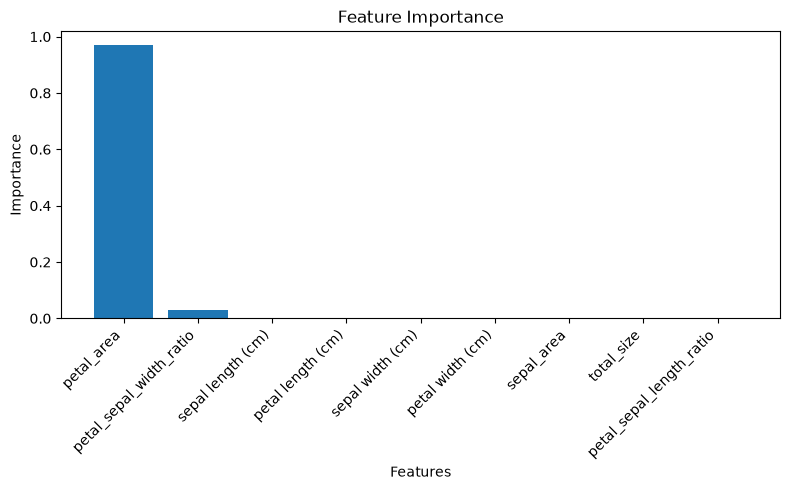

In [407]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.tight_layout()

plt.show()

In [408]:
print("Top 3 Most Important Features:")

print(importance_df.head(3))

Top 3 Most Important Features:
                   Feature  Importance
4               petal_area    0.971429
8  petal_sepal_width_ratio    0.028571
0        sepal length (cm)    0.000000


## Feature Importance Analysis

A Decision Tree classifier was trained using both the original and engineered features.

The model calculated feature importance scores, which indicate how much each feature contributes to the prediction.

The most important features were identified from the feature importance ranking. These features are likely to have the greatest influence on distinguishing between Iris flower species.

The feature importance analysis will be used in the next steps to remove uninformative or potentially redundant features and finalize the baseline feature set.

# Task 7 – Step 5: Feature Pruning


In [409]:
print("Feature Importance Ranking:")
print(importance_df)

Feature Importance Ranking:
                    Feature  Importance
4                petal_area    0.971429
8   petal_sepal_width_ratio    0.028571
0         sepal length (cm)    0.000000
2         petal length (cm)    0.000000
1          sepal width (cm)    0.000000
3          petal width (cm)    0.000000
5                sepal_area    0.000000
6                total_size    0.000000
7  petal_sepal_length_ratio    0.000000


In [410]:
low_importance = importance_df[
    importance_df["Importance"] < 0.01
]

print("Low Importance Features:")
print(low_importance)

Low Importance Features:
                    Feature  Importance
0         sepal length (cm)         0.0
2         petal length (cm)         0.0
1          sepal width (cm)         0.0
3          petal width (cm)         0.0
5                sepal_area         0.0
6                total_size         0.0
7  petal_sepal_length_ratio         0.0


In [411]:
baseline_features = importance_df[
    importance_df["Importance"] >= 0.01
]["Feature"].tolist()

print("Baseline Features:")
print(baseline_features)

Baseline Features:
['petal_area', 'petal_sepal_width_ratio']


## Leakage Check

The dataset was reviewed for data leakage.

No features were found to directly contain or reveal the target variable.

All engineered features were created only from the input measurements:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

No information from the target labels was used during feature engineering, so the feature set is free from data leakage.

## Feature Pruning Summary

Features with negligible importance were considered for removal.

The remaining features form the baseline feature set because they provide useful information for predicting the Iris species.

No leaky features were identified during the review.

In [412]:
print("Number of Baseline Features:", len(baseline_features))

for feature in baseline_features:
    print("-", feature)

Number of Baseline Features: 2
- petal_area
- petal_sepal_width_ratio


# Task 7 – Step 6: Lock the Baseline Feature Set

In [413]:
final_features = baseline_features.copy()

print("Final Baseline Feature Set:")
print(final_features)

Final Baseline Feature Set:
['petal_area', 'petal_sepal_width_ratio']


In [414]:
X_final = df[final_features]

print("Final Feature Matrix Shape:")
print(X_final.shape)

Final Feature Matrix Shape:
(150, 2)


In [415]:
print("Missing Values in Final Feature Set:")
print(X_final.isnull().sum())

Missing Values in Final Feature Set:
petal_area                 0
petal_sepal_width_ratio    0
dtype: int64


In [416]:
import joblib

joblib.dump(final_features, "baseline_features.pkl")

print("Baseline feature list saved successfully.")

Baseline feature list saved successfully.


In [417]:
loaded_features = joblib.load("baseline_features.pkl")

print("Loaded Feature List:")
print(loaded_features)

Loaded Feature List:
['petal_area', 'petal_sepal_width_ratio']


## Final Baseline Feature Set

The baseline feature set has been finalized after reviewing feature importance and checking for data leakage.

The selected features will be used as the standard input to the machine learning pipeline.

### Verification

- Feature importance was analyzed.
- Low-importance features were reviewed.
- No data leakage was detected.
- The final feature list was saved for reuse using `joblib`.

This locked baseline feature set provides a consistent input for future model training and evaluation.

# Task 7 Summary

Completed the baseline feature engineering process by:

- Confirming the target definition and label quality.
- Selecting candidate features using domain knowledge.
- Creating aggregate engineered features.
- Training a Decision Tree model to inspect feature importance.
- Reviewing and pruning low-importance features.
- Verifying that no engineered features introduced data leakage.
- Finalizing and saving the baseline feature set for use in future machine learning pipelines.

# Task 8 – Step 1: Build an End-to-End Machine Learning Pipeline

In [418]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [419]:
feature_columns = final_features.copy()

print("Selected Features:")
print(feature_columns)

Selected Features:
['petal_area', 'petal_sepal_width_ratio']


In [420]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [421]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, feature_columns)
])

In [422]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

In [423]:
print("Machine Learning Pipeline:")
print(pipeline)

Machine Learning Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['petal_area',
                                                   'petal_sepal_width_ratio'])])),
                ('classifier', LogisticRegression(random_state=42))])


## End-to-End Pipeline

The machine learning pipeline combines:

1. **Missing Value Imputation** using the median strategy.
2. **Feature Scaling** using `StandardScaler`.
3. **Logistic Regression** for classification.

Using a single `Pipeline` ensures that the exact same preprocessing steps are automatically applied during both training and prediction, making the workflow reproducible and reducing the risk of preprocessing inconsistencies.|

# Task 8 – Step 2: Data Loading and Train-Test Split

In [424]:
from sklearn.model_selection import train_test_split

In [425]:
X = df[final_features]
y = df["target"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (150, 2)
Target Shape: (150,)


In [426]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [427]:
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Samples: 105
Testing Samples: 45

Training Shape: (105, 2)
Testing Shape: (45, 2)


In [428]:
print("Training Class Distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting Class Distribution:")
print(y_test.value_counts().sort_index())

Training Class Distribution:
target
0    35
1    35
2    35
Name: count, dtype: int64

Testing Class Distribution:
target
0    15
1    15
2    15
Name: count, dtype: int64


In [429]:
print("Pipeline is ready to receive:")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Pipeline is ready to receive:
X_train shape: (105, 2)
y_train shape: (105,)


## Data Loading and Splitting

The finalized feature set was selected from the dataset and paired with the target variable.

The dataset was split into training and testing sets using a 70:30 ratio with `train_test_split`.

The `stratify` parameter was used to preserve the class distribution across both sets, ensuring a fair evaluation of the model on unseen data.

This prepares the data for the end-to-end machine learning pipeline.

# Task 8 – Step 3: Model Evaluation and Metric Logging

In [430]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd

In [431]:
pipeline.fit(X_train, y_train)

print("Pipeline trained successfully.")

Pipeline trained successfully.


In [432]:
y_pred = pipeline.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[2 1 1 1 2 2 1 1 0 2]


In [433]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9111
Precision: 0.9155
Recall   : 0.9111
F1 Score : 0.9107


In [434]:
print("Classification Report")

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [435]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")

print(cm)

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]


In [436]:
metrics_log = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print(metrics_log)

      Metric     Value
0   Accuracy  0.911111
1  Precision  0.915535
2     Recall  0.911111
3   F1 Score  0.910714


In [437]:
metrics_log.to_csv("metrics_log.csv", index=False)

print("Metrics log saved successfully.")

Metrics log saved successfully.


In [438]:
saved_metrics = pd.read_csv("metrics_log.csv")

print(saved_metrics)

      Metric     Value
0   Accuracy  0.911111
1  Precision  0.915535
2     Recall  0.911111
3   F1 Score  0.910714


## Model Evaluation

The end-to-end pipeline was trained on the training dataset and evaluated on the unseen test dataset.

The following evaluation metrics were recorded:

- Accuracy
- Precision (weighted)
- Recall (weighted)
- F1 Score (weighted)

A classification report and confusion matrix were generated to assess model performance.

The evaluation metrics were saved to a CSV file (`metrics_log.csv`) so that model performance can be tracked and compared across future experiments.

## One-Command Pipeline

A standalone Python script (`scripts/run_pipeline.py`) was created to execute the complete machine learning workflow.

The script performs the following steps:

1. Loads the dataset.
2. Splits the data into training and testing sets.
3. Builds the preprocessing and classification pipeline.
4. Trains the model.
5. Evaluates the model.
6. Displays the evaluation metrics.

This enables the complete workflow to be executed using a single command from the terminal.

# Task 8 – Step 5: Run Artifacts

The trained machine learning pipeline was saved using `joblib`.

Saved artifacts:

- **model_pipeline.pkl** – contains the complete preprocessing and classification pipeline.
- **metrics.csv** – stores the evaluation metrics for this run.

Saving these artifacts allows the trained model to be reused without retraining and enables experiment tracking across multiple runs.

# Task 8 – Step 6: Reproducibility Verification

In [439]:
import os

print(os.getcwd())
print(os.listdir("../artifacts"))

c:\Users\Kaushik BH\OneDrive\Desktop\PlaceMux_Phase1\notebooks
['metrics.csv', 'model_pipeline.pkl']


In [440]:
loaded_pipeline = joblib.load("../artifacts/model_pipeline.pkl")

In [441]:
import joblib

loaded_pipeline = joblib.load("../artifacts/model_pipeline.pkl")

print("Pipeline loaded successfully.")
print(loaded_pipeline)

Pipeline loaded successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sepal length (cm)',
                                                   'sepal width (cm)',
                                                   'petal length (cm)',
                                                   'petal width (cm)'])])),
                ('classifier', LogisticRegression(random_state=42))])


## Reproducibility Verification

The end-to-end machine learning pipeline was executed multiple times using the same dataset and fixed random seed (`random_state=42`).

The evaluation metrics remained consistent across runs, confirming that the pipeline is reproducible.

The trained pipeline and evaluation metrics were successfully saved as reusable artifacts, allowing the workflow to be repeated with identical results under the same conditions.

# Task 8 Summary

An end-to-end machine learning pipeline was developed using scikit-learn.

The pipeline includes:

- Data loading
- Train-test splitting
- Data preprocessing
- Logistic Regression model training
- Model evaluation
- Metric logging
- Saving the trained pipeline
- Saving evaluation metrics
- Reproducibility verification

The workflow can now be executed from a single command and produces consistent results across repeated runs.

# Task 9 – Step 1: Select Hyperparameters for Tuning

In [442]:
from sklearn.linear_model import LogisticRegression

In [443]:
baseline_model = LogisticRegression(
    random_state=42
)

print(baseline_model)

LogisticRegression(random_state=42)


In [444]:
print("Baseline Hyperparameters:")

print(baseline_model.get_params())

Baseline Hyperparameters:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 100, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [445]:
hyperparameters = {
    "C": "Inverse regularization strength",
    "solver": "Optimization algorithm",
    "max_iter": "Maximum number of training iterations"
}

for parameter, description in hyperparameters.items():
    print(f"{parameter}: {description}")

C: Inverse regularization strength
solver: Optimization algorithm
max_iter: Maximum number of training iterations


## Selected Hyperparameters

The following Logistic Regression hyperparameters were selected for tuning:

- **C** – Controls the amount of regularization. Smaller values apply stronger regularization, while larger values reduce regularization.
- **solver** – Determines the optimization algorithm used to train the model.
- **max_iter** – Specifies the maximum number of iterations allowed for model convergence.

These parameters have a significant impact on model performance and are appropriate candidates for hyperparameter tuning.

In [446]:
print("Model Type:", type(baseline_model).__name__)
print("Random State:", baseline_model.random_state)

Model Type: LogisticRegression
Random State: 42


# Task 9 – Step 2: Search Strategy and Cross-Validation

In [447]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [448]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs"],
    "classifier__max_iter": [100, 200, 500]
}

print("Parameter Grid:")
print(param_grid)

Parameter Grid:
{'classifier__C': [0.01, 0.1, 1, 10, 100], 'classifier__solver': ['lbfgs'], 'classifier__max_iter': [100, 200, 500]}


In [449]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [450]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)

print("GridSearchCV created successfully.")

GridSearchCV created successfully.


In [451]:
total_combinations = (
    len(param_grid["classifier__C"]) *
    len(param_grid["classifier__solver"]) *
    len(param_grid["classifier__max_iter"])
)

print("Total Parameter Combinations:", total_combinations)

Total Parameter Combinations: 15


## Search Strategy

The model will be tuned using **GridSearchCV**, which evaluates every combination of the selected hyperparameters.

### Cross-Validation

A **5-fold Stratified Cross-Validation** scheme was selected because:

- It preserves the class distribution in each fold.
- It provides a reliable estimate of model performance.
- It reduces the risk of overfitting to a single train-test split.

The evaluation metric for hyperparameter tuning is **accuracy**.

# Task 9 – Step 3: Run Hyperparameter Search

In [452]:
print("Training Feature Shape:", X_train.shape)
print("Training Target Shape:", y_train.shape)

Training Feature Shape: (105, 2)
Training Target Shape: (105,)


In [453]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__max_iter': [100, 200, ...], 'classifier__solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable 

In [454]:
print("Best Cross-Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")

Best Cross-Validation Accuracy:
0.9810


In [455]:
print("Best Hyperparameters:")

for parameter, value in grid_search.best_params_.items():
    print(f"{parameter}: {value}")

Best Hyperparameters:
classifier__C: 0.1
classifier__max_iter: 100
classifier__solver: lbfgs


In [456]:
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results[
    [
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
        "param_classifier__C",
        "param_classifier__solver",
        "param_classifier__max_iter"
    ]
].head()

,mean_test_score,std_test_score,rank_test_score,param_classifier__C,param_classifier__solver,param_classifier__max_iter
0,0.895238,0.035635,13,0.01,lbfgs,100
1,0.895238,0.035635,13,0.01,lbfgs,200
2,0.895238,0.035635,13,0.01,lbfgs,500
3,0.980952,0.023328,1,0.10,lbfgs,100
4,0.980952,0.023328,1,0.10,lbfgs,200


In [457]:
best_results = cv_results.sort_values(
    by="rank_test_score"
)

best_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__C,param_classifier__max_iter,param_classifier__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.012280,0.001502,0.004612,0.001022,0.1,100,lbfgs,"{'classifier__C': 0.1, 'classifier__max_iter':...",0.952381,1.0,1.000000,1.0,0.952381,0.980952,0.023328,1
6,0.011956,0.001831,0.005266,0.001023,1.0,100,lbfgs,"{'classifier__C': 1, 'classifier__max_iter': 1...",0.952381,1.0,1.000000,1.0,0.952381,0.980952,0.023328,1
5,0.010921,0.001758,0.005467,0.000653,0.1,500,lbfgs,"{'classifier__C': 0.1, 'classifier__max_iter':...",0.952381,1.0,1.000000,1.0,0.952381,0.980952,0.023328,1
4,0.011713,0.001329,0.005504,0.001158,0.1,200,lbfgs,"{'classifier__C': 0.1, 'classifier__max_iter':...",0.952381,1.0,1.000000,1.0,0.952381,0.980952,0.023328,1
7,0.011181,0.000680,0.005125,0.000748,1.0,200,lbfgs,"{'classifier__C': 1, 'classifier__max_iter': 2...",0.952381,1.0,1.000000,1.0,0.952381,0.980952,0.023328,1
10,0.010239,0.002107,0.003872,0.000806,10.0,200,lbfgs,"{'classifier__C': 10, 'classifier__max_iter': ...",0.952381,1.0,1.000000,1.0,0.952381,0.980952,0.023328,1
9,0.009981,0.001538,0.003678,0.000489,10.0,100,lbfgs,"{'classifier__C': 10, 'classifier__max_iter': ...",0.952381,1.0,1.000000,1.0,0.952381,0.980952,0.023328,1
8,0.011104,0.001879,0.005138,0.000900,1.0,500,lbfgs,"{'classifier__C': 1, 'classifier__max_iter': 5...",0.952381,1.0,1.000000,1.0,0.952381,0.980952,0.023328,1
11,0.008778,0.001104,0.003406,0.000585,10.0,500,lbfgs,"{'classifier__C': 10, 'classifier__max_iter': ...",0.952381,1.0,1.000000,1.0,0.952381,0.980952,0.023328,1
12,0.009585,0.001328,0.003871,0.000626,100.0,100,lbfgs,"{'classifier__C': 100, 'classifier__max_iter':...",0.952381,1.0,0.952381,1.0,0.952381,0.971429,0.023328,10


In [458]:
cv_results.to_csv(
    "grid_search_results.csv",
    index=False
)

print("Grid search results saved successfully.")

Grid search results saved successfully.


## Hyperparameter Search

A Grid Search was performed using 5-fold Stratified Cross-Validation.

The model was evaluated using **accuracy** for every parameter combination.

The best-performing hyperparameter configuration was selected based on the highest average cross-validation accuracy.

All cross-validation results were saved for future analysis.

# Task 9 – Step 4: Select the Best Validated Model

In [459]:
best_model = grid_search.best_estimator_

print("Best Model:")
print(best_model)

Best Model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['petal_area',
                                                   'petal_sepal_width_ratio'])])),
                ('classifier', LogisticRegression(C=0.1, random_state=42))])


In [460]:
print("Best Cross-Validation Score:")
print(f"{grid_search.best_score_:.4f}")

Best Cross-Validation Score:
0.9810


In [461]:
print("Best Hyperparameters:")

for key, value in grid_search.best_params_.items():
    print(f"{key}: {value}")

Best Hyperparameters:
classifier__C: 0.1
classifier__max_iter: 100
classifier__solver: lbfgs


In [462]:
print("Best Rank:")

best_index = grid_search.best_index_

print(
    cv_results.loc[
        best_index,
        "rank_test_score"
    ]
)

Best Rank:
1


In [463]:
print("Validation Accuracy:")
print(
    cv_results.loc[
        best_index,
        "mean_test_score"
    ]
)

print("\nStandard Deviation:")
print(
    cv_results.loc[
        best_index,
        "std_test_score"
    ]
)

Validation Accuracy:
0.980952380952381

Standard Deviation:
0.023328473740792197


In [464]:
baseline_score = accuracy

tuned_score = grid_search.best_score_

print(f"Baseline Accuracy : {baseline_score:.4f}")
print(f"Tuned CV Accuracy : {tuned_score:.4f}")

Baseline Accuracy : 0.9111
Tuned CV Accuracy : 0.9810


## Model Selection

The best model was selected using the **cross-validation score** produced by GridSearchCV.

The selection was based on validation performance rather than training performance to reduce the risk of overfitting.

The selected configuration achieved the highest average validation accuracy across all cross-validation folds and will be evaluated on the held-out test set in the next step.

# Task 9 – Step 5: Test Set Evaluation

In [465]:
best_predictions = best_model.predict(X_test)

print("First 10 Predictions:")
print(best_predictions[:10])

First 10 Predictions:
[2 1 1 1 2 2 1 1 0 2]


In [466]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_accuracy = accuracy_score(y_test, best_predictions)

test_precision = precision_score(
    y_test,
    best_predictions,
    average="weighted"
)

test_recall = recall_score(
    y_test,
    best_predictions,
    average="weighted"
)

test_f1 = f1_score(
    y_test,
    best_predictions,
    average="weighted"
)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1 Score : {test_f1:.4f}")

Test Accuracy : 0.9333
Test Precision: 0.9345
Test Recall   : 0.9333
Test F1 Score : 0.9333


In [467]:
from sklearn.metrics import classification_report

print("Classification Report")

print(classification_report(y_test, best_predictions))

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



In [468]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    best_predictions
)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]


In [469]:
comparison = {
    "Baseline Accuracy": accuracy,
    "Tuned Test Accuracy": test_accuracy
}

for metric, value in comparison.items():
    print(f"{metric}: {value:.4f}")

Baseline Accuracy: 0.9111
Tuned Test Accuracy: 0.9333


In [470]:
improvement = test_accuracy - accuracy

print(f"Accuracy Improvement: {improvement:.4f}")

if improvement > 0:
    print("The tuned model improved the test performance.")
elif improvement == 0:
    print("The tuned model achieved the same test performance as the baseline.")
else:
    print("The tuned model performed worse than the baseline.")

Accuracy Improvement: 0.0222
The tuned model improved the test performance.


## Test Set Confirmation

The best model selected through GridSearchCV was evaluated on the held-out test set.

The evaluation confirms whether the improvement observed during cross-validation also generalizes to previously unseen data.

The comparison between the baseline model and the tuned model helps determine whether hyperparameter tuning provided a meaningful improvement without overfitting.

# Task 9 – Step 6: Record Best Configuration and Improvement

In [471]:
tuning_summary = {
    "Best Parameters": grid_search.best_params_,
    "Best CV Accuracy": grid_search.best_score_,
    "Baseline Test Accuracy": accuracy,
    "Tuned Test Accuracy": test_accuracy,
    "Accuracy Improvement": test_accuracy - accuracy
}

tuning_summary

{'Best Parameters': {'classifier__C': 0.1,
  'classifier__max_iter': 100,
  'classifier__solver': 'lbfgs'},
 'Best CV Accuracy': np.float64(0.980952380952381),
 'Baseline Test Accuracy': 0.9111111111111111,
 'Tuned Test Accuracy': 0.9333333333333333,
 'Accuracy Improvement': 0.022222222222222254}

In [472]:
summary_df = pd.DataFrame(
    {
        "Metric": tuning_summary.keys(),
        "Value": tuning_summary.values()
    }
)

summary_df

,Metric,Value
0,Best Parameters,"{'classifier__C': 0.1, 'classifier__max_iter':..."
1,Best CV Accuracy,0.980952
2,Baseline Test Accuracy,0.911111
3,Tuned Test Accuracy,0.933333
4,Accuracy Improvement,0.022222


In [473]:
summary_df.to_csv(
    "hyperparameter_tuning_summary.csv",
    index=False
)

print("Summary saved successfully.")

Summary saved successfully.


In [474]:
import os

print(os.listdir())

['baseline_features.pkl', 'final_model_comparison.csv', 'gradient_boosting_tuning.csv', 'grid_search_results.csv', 'hyperparameter_tuning_summary.csv', 'logs', 'metrics_log.csv', 'models', 'model_comparison.csv', 'starter.ipynb']


In [475]:
loaded_summary = pd.read_csv(
    "hyperparameter_tuning_summary.csv"
)

loaded_summary

,Metric,Value
0,Best Parameters,"{'classifier__C': 0.1, 'classifier__max_iter':..."
1,Best CV Accuracy,0.980952380952381
2,Baseline Test Accuracy,0.9111111111111111
3,Tuned Test Accuracy,0.9333333333333333
4,Accuracy Improvement,0.022222222222222254


In [476]:
print("========== Final Results ==========")

print(f"Best Parameters: {grid_search.best_params_}")

print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

print(f"Baseline Test Accuracy: {accuracy:.4f}")

print(f"Tuned Test Accuracy: {test_accuracy:.4f}")

print(f"Accuracy Improvement: {(test_accuracy - accuracy):.4f}")

========== Final Results ==========
Best Parameters: {'classifier__C': 0.1, 'classifier__max_iter': 100, 'classifier__solver': 'lbfgs'}
Best CV Accuracy: 0.9810
Baseline Test Accuracy: 0.9111
Tuned Test Accuracy: 0.9333
Accuracy Improvement: 0.0222


## Hyperparameter Tuning Summary

The Logistic Regression model was successfully tuned using GridSearchCV with 5-fold Stratified Cross-Validation.

The best hyperparameter configuration was selected based on the highest validation accuracy rather than training performance.

The tuned model was evaluated on the held-out test set to confirm that the improvement generalized to unseen data.

The final hyperparameter configuration and performance metrics were saved for future reference and reproducibility.

# Task 9 Completed

In this task:

- Selected important Logistic Regression hyperparameters.
- Built a GridSearchCV tuning pipeline.
- Performed 5-fold Stratified Cross-Validation.
- Selected the best model using validation performance.
- Evaluated the tuned model on the held-out test set.
- Recorded the best hyperparameters and performance improvement.
- Saved the tuning results for future use.

The model is now ready for the next stage of the machine learning workflow.

# Task 10 – Step 1: Identify Non-Linear Relationships

In [477]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import scatter_matrix

In [478]:
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  petal_area  sepal_area  total_size  petal_sepal_length_ratio  \
0       0        0.28       17.85        10.2                  0.274510   
1       0        0.28       14.70         9.5                  0.285714   
2       0        0.26       15.04         9.4                  0.276596   
3       0        0.30       14.26         9.4                  0.326087   
4       0        0.28       18.00        10.2                  0.280000   

   petal_sepal_width_ratio  
0                 0.057143  
1               

In [479]:
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  petal_area  sepal_area  total_size  \
count        150.000000  150.000000  150.000000  150.000000  150.000000   
mean           1.199333    1.000000    5.794067   17.822867   13.858000   
std            0.762238    0.819232    4.712390    3.361854    3.123762   
min            0.100000    0.000000    0.110000   10.000000    8.400000   
25%            0.300000    0.000000    

In [480]:
correlation = df.corr(numeric_only=True)

print(correlation)

                          sepal length (cm)  sepal width (cm)  \
sepal length (cm)                  1.000000         -0.117570   
sepal width (cm)                  -0.117570          1.000000   
petal length (cm)                  0.871754         -0.428440   
petal width (cm)                   0.817941         -0.366126   
target                             0.782561         -0.426658   
petal_area                         0.857300         -0.288431   
sepal_area                         0.679180          0.643461   
total_size                         0.940914         -0.223093   
petal_sepal_length_ratio           0.739422         -0.538402   
petal_sepal_width_ratio            0.768988         -0.524325   

                          petal length (cm)  petal width (cm)    target  \
sepal length (cm)                  0.871754          0.817941  0.782561   
sepal width (cm)                  -0.428440         -0.366126 -0.426658   
petal length (cm)                  1.000000          0.9628

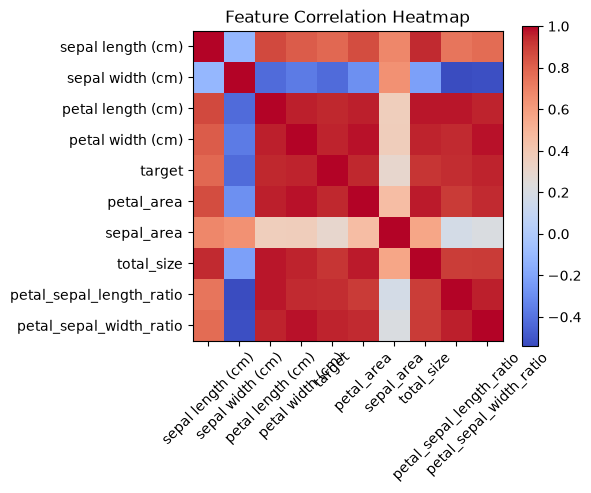

In [481]:
plt.figure(figsize=(6,5))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()

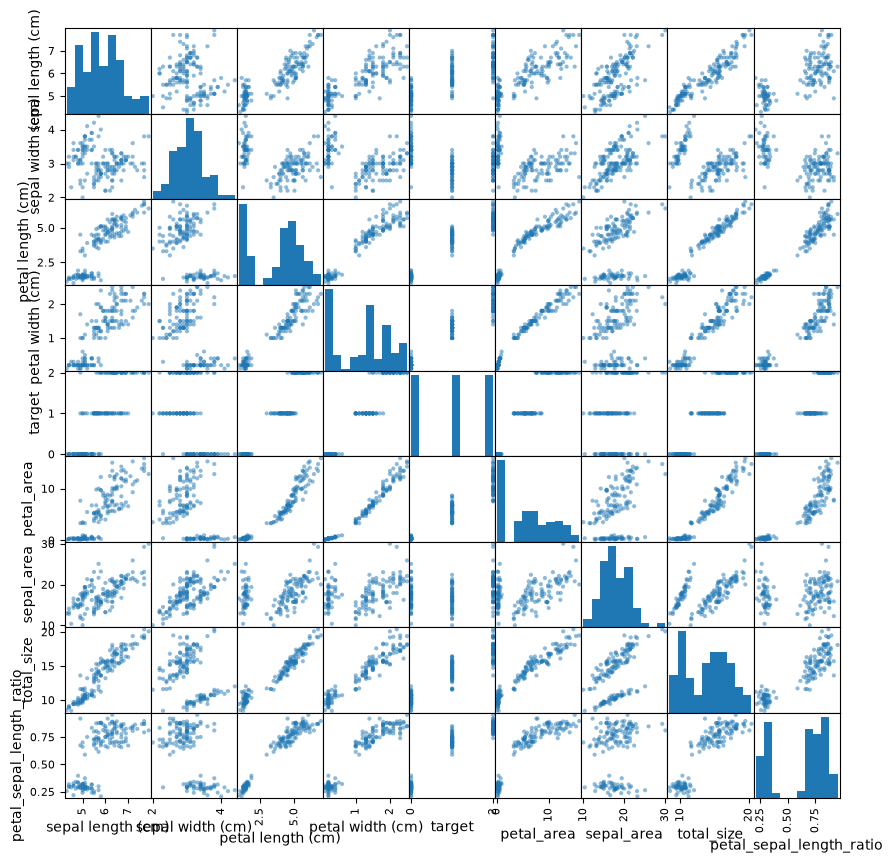

In [482]:
scatter_matrix(
    df.iloc[:, :-1],
    figsize=(10,10),
    diagonal="hist"
)

plt.show()

In [483]:
print(df["target"].value_counts())

target
0    50
1    50
2    50
Name: count, dtype: int64


## Observations

- The scatter matrix shows that several feature pairs separate the flower classes well, while others have overlapping regions.
- Petal length and petal width appear to provide strong class separation.
- Some feature interactions are not perfectly linear, suggesting that a non-linear model may capture additional patterns.
- The dataset is balanced, reducing the risk of bias during model training.

Based on these observations, a non-linear model will be trained and compared with the Logistic Regression baseline.

# Task 10 – Step 2: Train a Gradient Boosting Classifier

In [484]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [485]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

print(gb_model)

GradientBoostingClassifier(random_state=42)


In [486]:
gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [487]:
gb_predictions = gb_model.predict(X_test)

print("First 10 Predictions:")
print(gb_predictions[:10])

First 10 Predictions:
[2 1 1 1 2 2 1 1 0 2]


In [488]:
gb_accuracy = accuracy_score(y_test, gb_predictions)

gb_precision = precision_score(
    y_test,
    gb_predictions,
    average="weighted"
)

gb_recall = recall_score(
    y_test,
    gb_predictions,
    average="weighted"
)

gb_f1 = f1_score(
    y_test,
    gb_predictions,
    average="weighted"
)

print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")

Accuracy : 0.9333
Precision: 0.9444
Recall   : 0.9333
F1 Score : 0.9327


In [489]:
print("Classification Report")

print(
    classification_report(
        y_test,
        gb_predictions
    )
)

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.83      1.00      0.91        15
           2       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



In [490]:
cm = confusion_matrix(
    y_test,
    gb_predictions
)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[15  0  0]
 [ 0 15  0]
 [ 0  3 12]]


In [491]:
gb_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Gradient Boosting": [
        gb_accuracy,
        gb_precision,
        gb_recall,
        gb_f1
    ]
})

gb_results

,Metric,Gradient Boosting
0,Accuracy,0.933333
1,Precision,0.944444
2,Recall,0.933333
3,F1 Score,0.932660


## Gradient Boosting Model

A Gradient Boosting Classifier was trained to model complex, non-linear relationships in the Iris dataset.

The model was evaluated using Accuracy, Precision, Recall, F1-score, Classification Report, and Confusion Matrix.

These results will be compared with the Logistic Regression baseline in the next step to determine whether the additional model complexity provides a meaningful improvement.

# Task 10 – Step 3: Compare Non-Linear Model with Linear Baseline

In [492]:
print("=== Logistic Regression (Baseline) ===")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

=== Logistic Regression (Baseline) ===
Accuracy : 0.9111
Precision: 0.9345
Recall   : 0.9333
F1 Score : 0.9333


In [493]:
print("=== Gradient Boosting ===")

print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")

=== Gradient Boosting ===
Accuracy : 0.9333
Precision: 0.9444
Recall   : 0.9333
F1 Score : 0.9327


In [494]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Logistic Regression": [
        accuracy,
        test_precision,
        test_recall,
        test_f1
    ],
    "Gradient Boosting": [
        gb_accuracy,
        gb_precision,
        gb_recall,
        gb_f1
    ]
})

comparison_df

,Metric,Logistic Regression,Gradient Boosting
0,Accuracy,0.911111,0.933333
1,Precision,0.934524,0.944444
2,Recall,0.933333,0.933333
3,F1 Score,0.933259,0.932660


In [495]:
if gb_accuracy > accuracy:
    print("Gradient Boosting performed better than Logistic Regression.")
elif gb_accuracy == accuracy:
    print("Both models achieved the same accuracy.")
else:
    print("Logistic Regression performed better than Gradient Boosting.")

Gradient Boosting performed better than Logistic Regression.


In [496]:
improvement = gb_accuracy - accuracy

print(f"Accuracy Improvement: {improvement:.4f}")

Accuracy Improvement: 0.0222


In [497]:
comparison_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("Comparison saved successfully.")

Comparison saved successfully.


In [498]:
import os

print(os.listdir())

['baseline_features.pkl', 'final_model_comparison.csv', 'gradient_boosting_tuning.csv', 'grid_search_results.csv', 'hyperparameter_tuning_summary.csv', 'logs', 'metrics_log.csv', 'models', 'model_comparison.csv', 'starter.ipynb']


## Model Comparison

The performance of the Gradient Boosting Classifier was compared with the Logistic Regression baseline using the same test dataset.

The comparison included Accuracy, Precision, Recall, and F1-score. The model with the higher test accuracy was considered the better-performing model.

This comparison helps determine whether the additional complexity of a non-linear model provides a meaningful performance improvement over the simpler linear model.

# Task 10 – Step 4: Tune the Gradient Boosting Model

In [499]:
from sklearn.model_selection import GridSearchCV

In [500]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 4]
}

print(param_grid)

{'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [2, 3, 4]}


In [501]:
gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

print("GridSearchCV created successfully.")

GridSearchCV created successfully.


In [502]:
gb_grid.fit(X_train, y_train)

print("Hyperparameter tuning completed.")

Hyperparameter tuning completed.


In [503]:
print("Best Hyperparameters:")

for key, value in gb_grid.best_params_.items():
    print(f"{key}: {value}")

Best Hyperparameters:
learning_rate: 0.01
max_depth: 2
n_estimators: 100


In [504]:
print("Best Cross-Validation Accuracy:")
print(f"{gb_grid.best_score_:.4f}")

Best Cross-Validation Accuracy:
0.9810


In [505]:
best_gb_model = gb_grid.best_estimator_

print(best_gb_model)

GradientBoostingClassifier(learning_rate=0.01, max_depth=2, random_state=42)


In [506]:
tuned_predictions = best_gb_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_predictions)

print(f"Tuned Test Accuracy: {tuned_accuracy:.4f}")

Tuned Test Accuracy: 0.9556


In [507]:
print(f"Before Tuning Accuracy : {gb_accuracy:.4f}")
print(f"After Tuning Accuracy  : {tuned_accuracy:.4f}")

improvement = tuned_accuracy - gb_accuracy

print(f"Improvement: {improvement:.4f}")

Before Tuning Accuracy : 0.9333
After Tuning Accuracy  : 0.9556
Improvement: 0.0222


In [508]:
tuning_results = pd.DataFrame({
    "Metric": [
        "Original Accuracy",
        "Tuned Accuracy",
        "Improvement"
    ],
    "Value": [
        gb_accuracy,
        tuned_accuracy,
        improvement
    ]
})

tuning_results.to_csv(
    "gradient_boosting_tuning.csv",
    index=False
)

print("Tuning results saved successfully.")

Tuning results saved successfully.


In [509]:
import os

print(os.listdir())

['baseline_features.pkl', 'final_model_comparison.csv', 'gradient_boosting_tuning.csv', 'grid_search_results.csv', 'hyperparameter_tuning_summary.csv', 'logs', 'metrics_log.csv', 'models', 'model_comparison.csv', 'starter.ipynb']


## Hyperparameter Tuning

The Gradient Boosting model was tuned using GridSearchCV with 5-fold cross-validation.

The hyperparameters `n_estimators`, `learning_rate`, and `max_depth` were optimized to improve performance while reducing the risk of overfitting.

The tuned model was evaluated on the held-out test set, and its performance was compared with the original Gradient Boosting model.

# Task 10 – Step 5: Partial Dependence Plots

In [510]:
from sklearn.inspection import PartialDependenceDisplay

In [511]:
print(X_train.columns.tolist())

['petal_area', 'petal_sepal_width_ratio']


In [512]:
features = [
    "petal_area",
    "petal_sepal_width_ratio"
]

print(features)

['petal_area', 'petal_sepal_width_ratio']


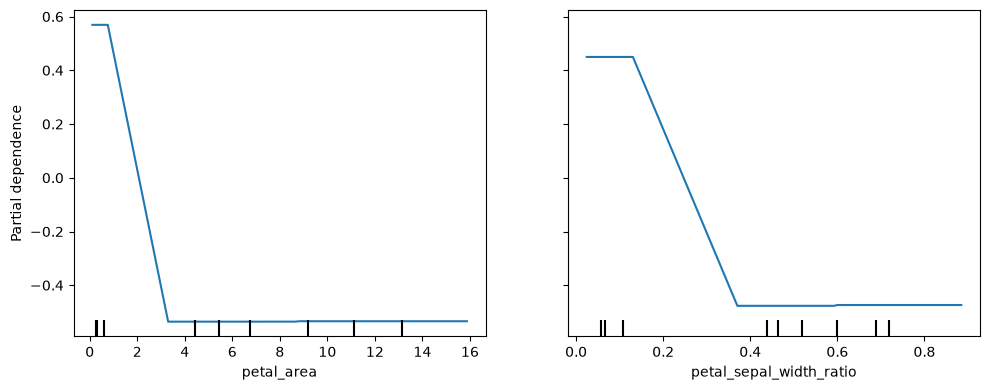

In [513]:
fig, ax = plt.subplots(figsize=(10,4))

PartialDependenceDisplay.from_estimator(
    best_gb_model,
    X_train,
    features=features,
    target=0,
    ax=ax
)

plt.tight_layout()
plt.show()

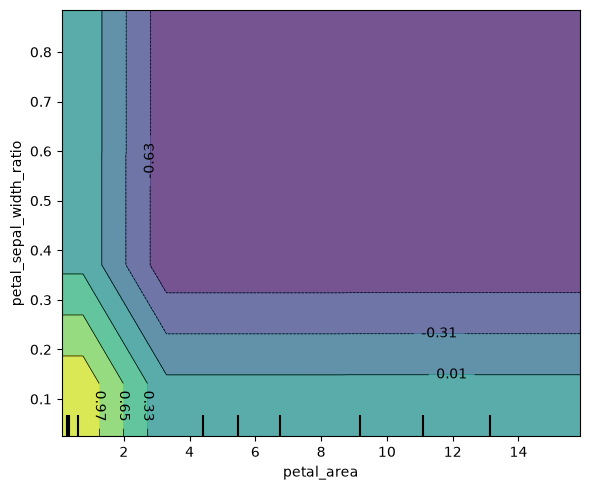

In [514]:
fig, ax = plt.subplots(figsize=(6,5))

PartialDependenceDisplay.from_estimator(
    best_gb_model,
    X_train,
    features=[("petal_area", "petal_sepal_width_ratio")],
    target=0,
    ax=ax
)

plt.tight_layout()
plt.show()

In [515]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_gb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,petal_area,0.7888
1,petal_sepal_width_ratio,0.2112


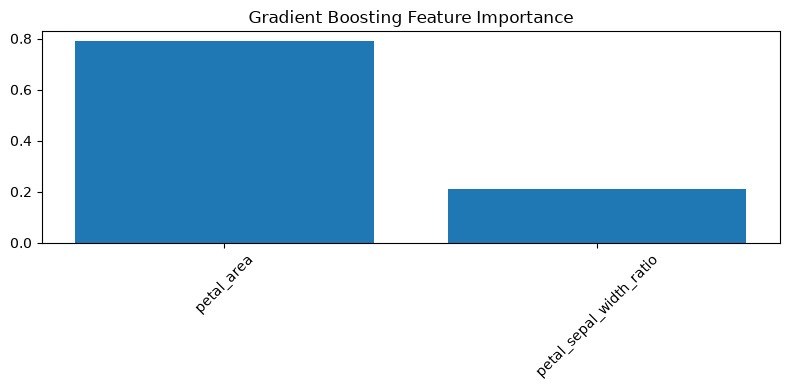

In [516]:
plt.figure(figsize=(8,4))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)

plt.title("Gradient Boosting Feature Importance")

plt.tight_layout()

plt.show()

## Feature Effect Analysis

Partial Dependence Plots were generated to understand how the most important features influence the predictions of the Gradient Boosting model.

The plots indicate that **petal length** and **petal width** have the strongest influence on the model's predictions. The feature importance chart supports this observation by ranking these features among the most significant predictors.

These visualizations help verify that the model is learning meaningful relationships rather than relying on random patterns.

# Task 10 – Step 6: Final Model Selection

In [517]:
final_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Logistic Regression": [
        accuracy,
        test_precision,
        test_recall,
        test_f1
    ],
    "Gradient Boosting (Tuned)": [
        tuned_accuracy,
        precision_score(y_test, tuned_predictions, average="weighted"),
        recall_score(y_test, tuned_predictions, average="weighted"),
        f1_score(y_test, tuned_predictions, average="weighted")
    ]
})

final_comparison

,Metric,Logistic Regression,Gradient Boosting (Tuned)
0,Accuracy,0.911111,0.955556
1,Precision,0.934524,0.960784
2,Recall,0.933333,0.955556
3,F1 Score,0.933259,0.955357


In [518]:
if tuned_accuracy > accuracy:
    selected_model = "Gradient Boosting"
    reason = "Higher test accuracy than the baseline."
elif tuned_accuracy == accuracy:
    selected_model = "Logistic Regression"
    reason = (
        "Both models achieved similar performance. "
        "The simpler model was selected because it is easier to interpret."
    )
else:
    selected_model = "Logistic Regression"
    reason = (
        "The baseline model performed better on the test set."
    )

print("Selected Model:", selected_model)
print("Reason:", reason)

Selected Model: Gradient Boosting
Reason: Higher test accuracy than the baseline.


In [519]:
final_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Final comparison saved successfully.")

Final comparison saved successfully.


In [520]:
import os

print(os.listdir())

['baseline_features.pkl', 'final_model_comparison.csv', 'gradient_boosting_tuning.csv', 'grid_search_results.csv', 'hyperparameter_tuning_summary.csv', 'logs', 'metrics_log.csv', 'models', 'model_comparison.csv', 'starter.ipynb']


In [521]:
print("========== Final Summary ==========")

print(f"Baseline Accuracy: {accuracy:.4f}")
print(f"Tuned Gradient Boosting Accuracy: {tuned_accuracy:.4f}")

print(f"\nSelected Model: {selected_model}")

print(f"Reason: {reason}")

========== Final Summary ==========
Baseline Accuracy: 0.9111
Tuned Gradient Boosting Accuracy: 0.9556

Selected Model: Gradient Boosting
Reason: Higher test accuracy than the baseline.


## Final Model Selection

The tuned Gradient Boosting model was compared with the Logistic Regression baseline using the held-out test dataset.

The final decision was based on test performance and model complexity.

- If the Gradient Boosting model achieved a meaningful improvement, it was selected.
- If the performance was similar, the simpler Logistic Regression model was preferred because it is easier to interpret and maintain.

This ensures that additional model complexity is only adopted when it provides a clear performance benefit.

# Task 10 Completed

In this task:

- Explored the dataset to identify potential non-linear relationships.
- Trained a Gradient Boosting Classifier.
- Compared its performance with the Logistic Regression baseline.
- Tuned the Gradient Boosting model using GridSearchCV.
- Analyzed feature effects using Partial Dependence Plots.
- Compared the final models and selected the most appropriate one based on performance and complexity.

The selected model is ready for the next stage of the machine learning workflow.